# K1 : Planification Urbaine et Placement d'Infrastructures

## 1. Description du problème

Ce sujet porte sur la **planification urbaine optimisée**. L'objectif est de déterminer les emplacements idéaux pour diverses infrastructures (hôpitaux, écoles, centres commerciaux, parcs, stations de recharge) au sein d'une zone urbaine.

Il s'agit d'un problème classique de **Théorie de la Localisation**, dont les trois variantes principales sont :

| Problème | Objectif | Usage typique |
|---|---|---|
| **p-median** | Minimiser la distance totale population↔infrastructure | Entrepôts logistiques |
| **p-center** | Minimiser la distance maximale (équité) | Urgences, pompiers |
| **MCLP** (Maximal Covering Location Problem) | Maximiser la population couverte sous un rayon fixé | Hôpitaux, écoles |

Ce notebook implémente une **variante MCLP enrichie** avec CP-SAT, intégrant :
- Une contrainte de **budget** (nombre maximal de nouvelles infrastructures),
- Un rayon de **distance maximale** (un site ne couvre un district que s'il est à moins de `radius_km`),
- Une contrainte d'**équité** (minimiser l'écart de couverture entre districts),
- Des contraintes de **compatibilité** (espacement minimal entre sites du même type).

Les données utilisées proviennent d'**OpenStreetMap (OSM)** via la bibliothèque `osmnx`.

### Bibliothèques principales

- **Optimisation** : `ortools` (module `cp_model`) — solveur CP-SAT de Google.
- **Géographie** : `geopandas` (manipulation de données spatiales), `osmnx` (extraction OSM).
- **Cartographie** : `folium` (cartes interactives HTML).

### Configuration globale

Tous les paramètres modifiables sont centralisés ici.

In [1]:
import folium
import folium.plugins
import geopandas as gpd
import matplotlib.pyplot as plt
import math
import os
import osmnx as ox
from IPython.display import IFrame, display
from ortools.sat.python import cp_model
from shapely.geometry import box
from typing import NamedTuple

In [2]:
# Ville cible
CITY = "Lyon, France"
DATA_DIR = "data"
DISTRICT_COUNT = 12  # Nombre approximatif de districts (mode grid)
DISTRICT_MODE = "predefined"  # "predefined" (limites admin OSM) ou "grid"

# Paramètres du solveur
BUDGET = 5  # Nombre maximal de nouvelles infrastructures
RADIUS_KM = 1.5  # Rayon de couverture en km
EQUITY_WEIGHT = 1.0  # Poids de l'équité (0 = couverture pure, >1 = très équitable)
MIN_SPACING_KM = 1.0  # Distance minimale entre deux sites du même type (compatibilité)
SOLVER_TIMEOUT_S = 60  # Temps max alloué au solveur (secondes)

# Chemins de sortie
CITY_DIR = os.path.join(DATA_DIR, CITY)
DISTRICTS_PATH = os.path.join(CITY_DIR, "districts.geojson")
SITES_PATH = os.path.join(CITY_DIR, "sites.geojson")
MAP_OUTPUT = "lyon_map.html"

## 2. Algorithme : CP-SAT

### Description du solveur OR-Tools CP-SAT

OR-Tools CP-SAT (Constraint Programming SAT) est un solveur de contraintes très performant développé par Google. Il est utilisé pour résoudre efficacement des problèmes complexes en optimisation et satisfaction de contraintes. On le retrouve dans des applications d'ordonnancement, d'affectation de ressources et d'autres problèmes combinatoires.

ORTools permet de modéliser des problèmes de décision sur des domaines finis, à l'aide de variables entières, de variables booléennes et de clauses. La librairie dispose d'un large panel de contraintes, dont des contraintes globales (`alldifferent`, `sum`, `circuit`, `cumulative`, `regular`, `table`, `reservoir`, etc.).

OR-Tools CP-SAT combine différentes approches : Programmation Par Contraintes (CP), SAT, mais aussi de la Programmation Linéaire. L'hybridation CP-SAT est basée sur le framework de **Génération Paresseuse de Clauses (LCG)**, mis en avant par le solveur Chuffed, qui aide le solveur à analyser ses propres conflits durant la recherche afin de mieux apprendre de ses erreurs. La Programmation Linéaire aide quant à elle le solveur à mieux exploiter la fonction d'optimisation.

Le solveur utilise par défaut un **Portfolio de solveurs** permettant de combiner simultanément différentes configurations afin de résoudre le problème le plus efficacement possible.

### Modélisation du problème MCLP

Le pseudo-code ci-dessous résume la structure du modèle CP-SAT implémenté dans ce notebook :

```
Variables:
  x[s] ∈ {0,1}   pour chaque site candidat s  (1 = sélectionné)
  y[d] ∈ {0,1}   pour chaque district d        (1 = couvert)
  cov[d] ∈ ℤ≥0   nombre de sites sélectionnés qui couvrent d

Contraintes:
  (Budget)        Σ x[s] ≤ budget
  (Couverture)    cov[d] = Σ{ x[s] | dist(s,d) ≤ R }    pour tout d
  (Activation)    y[d] ≤ cov[d]                           pour tout d
                  y[d] ≥ cov[d] / n_sites  (linéarisé via AddMaxEquality)
  (Compatibilité) x[s1] + x[s2] ≤ 1  si même type et dist(s1,s2) < min_spacing
  (Équité)        equity_gap = max(cov[d] | couvert) - min(cov[d] | couvert)

Objectif:
  Maximiser  SCALE * Σ y[d]  -  equity_weight * equity_gap
```

## 3. Chargement des données de Lyon

### Pourquoi Lyon ?

Lyon est un choix naturel pour valider ce type de modèle pour plusieurs raisons :

- **Richesse des données OSM** : Lyon dispose d'une couverture OpenStreetMap très complète (réseau routier, limites administratives des 9 arrondissements, points d'intérêt étiquetés).
- **Taille maîtrisée** : avec ~520 000 habitants sur ~48 km², la ville est assez grande pour que le problème de localisation soit non trivial, mais assez petite pour que les données restent gérables en mémoire.
- **Structure polycentriques** : la configuration de Lyon (presqu'île, rive gauche, collines) crée des contraintes géographiques réelles qui mettent à l'épreuve les heuristiques d'équité.
- **Découpage administratif clair** : les 9 arrondissements constituent des districts naturels bien délimités dans OSM (`admin_level=10`).

### Données chargées

La fonction `fetch_data` récupère via `osmnx` :
1. **`roads.geojson`** — réseau routier (pour détecter les zones accessibles).
2. **`districts.geojson`** — limites administratives (ou grille régulière en fallback).
3. **`sites.geojson`** — sites candidats existants (écoles, hôpitaux, parcs, supermarchés…) représentés par leurs centroïdes.

In [3]:
def fetch_data(
    city: str,
    output_dir: str = "data",
    district_count: int = 12,
    district_mode: str = "predefined",
) -> None:
    """Fetches and saves geographic data for the specified city.

    Creates three GeoJSON files inside `output_dir/{city}/`:
    - roads.geojson     : drivable road network
    - districts.geojson : administrative districts (or grid fallback)
    - sites.geojson     : candidate infrastructure sites (schools, hospitals, parks…)

    Parameters
    ----------
    city : str
        The city name as understood by OSM (e.g. "Lyon, France").
    output_dir : str, default="data"
        Root directory where the sub-folder will be created.
    district_count : int, default=12
        Approximate number of districts for the grid fallback.
    district_mode : str, default="predefined"
        "predefined" to use OSM administrative boundaries, "grid" to force
        a rectangular split of the bounding box.
    """
    print(f"Fetching data for {city}...")
    city_dir = os.path.join(output_dir, city)
    os.makedirs(city_dir, exist_ok=True)

    # City boundary
    city_boundary = ox.geocode_to_gdf(city)[["geometry"]].copy()
    if city_boundary.crs is not None and city_boundary.crs.to_string() != "EPSG:4326":
        city_boundary = city_boundary.to_crs(epsg=4326)
    city_boundary_geom = city_boundary.geometry.iloc[0]

    # Road network
    graph = ox.graph_from_place(city, network_type="drive")
    roads = ox.graph_to_gdfs(graph, nodes=False)[["geometry"]].copy()
    if roads.crs is not None and roads.crs.to_string() != "EPSG:4326":
        roads = roads.to_crs(epsg=4326)
    roads_path = os.path.join(city_dir, "roads.geojson")
    roads.to_file(roads_path, driver="GeoJSON")
    road_union = roads.geometry.union_all()

    # Districts
    districts = gpd.GeoDataFrame()

    if district_mode == "predefined":
        district_tags = {
            "boundary": "administrative",
            "admin_level": ["10", "9", "8"],
        }
        candidate_districts = ox.features_from_place(city, district_tags)
        # candidate_districts = candidate_districts[candidate_districts["name"].str.contains("Arrondissement", na=False)]
        if not candidate_districts.empty:
            candidate_districts = candidate_districts[candidate_districts.geometry.notna()].copy()
            if candidate_districts.crs is not None and candidate_districts.crs.to_string() != "EPSG:4326":
                candidate_districts = candidate_districts.to_crs(epsg=4326)
            candidate_districts = candidate_districts[candidate_districts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
            candidate_districts = candidate_districts.explode(index_parts=False, ignore_index=True)
            candidate_districts = candidate_districts[candidate_districts.geometry.intersects(city_boundary_geom)].copy()
            candidate_districts["geometry"] = candidate_districts.geometry.intersection(city_boundary_geom)
            candidate_districts = candidate_districts[~candidate_districts.geometry.is_empty].copy()
            candidate_districts = candidate_districts[candidate_districts.geometry.intersects(road_union)].copy()
            candidate_districts = candidate_districts.drop_duplicates(subset=["geometry"]).reset_index(drop=True)
            if not candidate_districts.empty:
                districts = gpd.GeoDataFrame(
                    candidate_districts[["geometry"]].copy(),
                    geometry="geometry",
                    crs="EPSG:4326",
                )

    # Fallback: uniform grid
    if districts.empty:
        print("  No predefined districts found — falling back to grid.")
        rows = max(1, int(math.floor(math.sqrt(district_count))))
        cols = max(1, int(math.ceil(district_count / rows)))
        minx, miny, maxx, maxy = city_boundary_geom.bounds
        cell_width = (maxx - minx) / cols
        cell_height = (maxy - miny) / rows
        district_geometries = []
        for row in range(rows):
            for col in range(cols):
                cell = box(
                    minx + col * cell_width,
                    miny + row * cell_height,
                    minx + (col + 1) * cell_width,
                    miny + (row + 1) * cell_height,
                )
                district = cell.intersection(city_boundary_geom)
                if not district.is_empty and district.intersects(road_union):
                    district_geometries.append(district)
        if not district_geometries:
            district_geometries = [city_boundary_geom]
        districts = gpd.GeoDataFrame(geometry=district_geometries, crs="EPSG:4326")

    districts_path = os.path.join(city_dir, "districts.geojson")
    districts.to_file(districts_path, driver="GeoJSON")

    # Candidate sites
    site_tags = {
        "amenity": [
            "school",
            "hospital",
            "clinic",
            "university",
            "kindergarten",
            "library",
            "college",
        ],
        "leisure": ["park", "sports_centre"],
        "shop": ["supermarket"],
    }
    sites = ox.features_from_place(city, site_tags)
    if not sites.empty:
        sites = sites[sites.geometry.notna()].copy()
        if sites.crs is not None and sites.crs.to_string() != "EPSG:4326":
            sites = sites.to_crs(epsg=4326)
        sites["geometry"] = sites.geometry.representative_point()
        site_columns = [col for col in ["geometry", "name", "amenity", "leisure", "shop"] if col in sites.columns]
        sites = sites[site_columns].copy()
    else:
        sites = districts[["geometry"]].copy()
        sites["name"] = city
        sites["amenity"] = "city_boundary"

    district_union = districts.geometry.union_all()
    sites = sites[sites.geometry.apply(district_union.covers)].copy()

    sites_path = os.path.join(city_dir, "sites.geojson")
    sites.to_file(sites_path, driver="GeoJSON")

    print(f"  {len(districts)} districts, {len(sites)} candidate sites saved to {city_dir}/")

In [4]:
def visualize_data(city: str, data_dir: str = "data") -> None:
    """Visualizes the data for the specified city.

    Visualizes the road network data for the specified city using Folium.
    Show the result in the console.

    Parameters
    ----------
    city : str
        The city for which to visualize data.
    data_dir : str, default="data"
        The directory where the fetched data is saved.
    """
    print(f"Visualizing data for {city} from {data_dir}...")
    data_path = os.path.join(data_dir, f"{city.replace(' ', '_')}_roads.geojson")
    gdf = gpd.read_file(data_path)

    if gdf.crs is not None and gdf.crs.to_string() != "EPSG:4326":
        gdf = gdf.to_crs(epsg=4326)

    road_geometry = gdf[["geometry"]].copy()
    bounds = road_geometry.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)
    folium.GeoJson(road_geometry, name="road network").add_to(m)
    display(m)

In [5]:
fetch_data(
    city=CITY,
    output_dir=DATA_DIR,
    district_count=DISTRICT_COUNT,
    district_mode=DISTRICT_MODE,
)

# Vérification rapide des fichiers générés
for path in (DISTRICTS_PATH, SITES_PATH):
    assert os.path.exists(path), f"Fichier manquant : {path}"
    gdf = gpd.read_file(path)
    print(f"{path} → {len(gdf)} entités")

# Beware, this map will not be displayed in VSCODE,
# you need the geo-data-viewer extension and look at the json file
# visualize_data(city=CITY)

Fetching data for Lyon, France...
  28 districts, 1232 candidate sites saved to data\Lyon, France/
data\Lyon, France\districts.geojson → 28 entités
data\Lyon, France\sites.geojson → 1232 entités


## 4. Solveur CP-SAT

La fonction `solve` construit et résout le modèle CP-SAT décrit en section 2 :

1. **Chargement des données** : districts et sites lus depuis les GeoJSON. Les centroïdes des districts sont calculés en projection métrique (EPSG:3857) puis reprojettés en WGS-84.

2. **Matrice de couverture** : distance de Haversine entre chaque centroïde de district et chaque site. Si `dist ≤ radius_km`, le site couvre le district.

3. **Variables CP-SAT** :
   - `x[s]` (BoolVar) : 1 si le site `s` est sélectionné.
   - `y[d]` (BoolVar) : 1 si le district `d` est couvert par au moins un site sélectionné.
   - `cov[d]` (IntVar) : nombre de sites sélectionnés couvrant le district `d`.

4. **Contraintes** :
   - **Budget** : `Σ x[s] ≤ budget`
   - **Activation** : `cov[d] ≥ y[d]` et `cov[d] ≤ y[d] * |cover(d)|` (fermeture du modèle)
   - **Compatibilité** : pour deux sites `s1, s2` du même type trop proches : `x[s1] + x[s2] ≤ 1`
   - **Équité** : `equity_gap = max(cov[d] | couvert) − min(cov[d] | couvert)`

5. **Objectif** : `Maximiser SCALE * Σ y[d] − equity_weight * equity_gap`

In [6]:
def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Return the great-circle distance in kilometres between two WGS-84 points."""
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return R * 2 * math.asin(math.sqrt(a))

In [7]:
class SolveResult(NamedTuple):
    """Result returned by solve().

    Attributes
    ----------
    selected_sites : list[int]
        Indices of the sites chosen by the solver.
    covered_districts : list[int]
        Indices of the districts covered by the solution.
    district_coverage_count : list[int]
        For each district, the number of selected sites that cover it.
    """

    selected_sites: list[int]
    covered_districts: list[int]
    district_coverage_count: list[int]


def site_label(row) -> str:
    """Return the display type for a site row."""
    for col in ("amenity", "leisure", "shop"):
        val = row.get(col)
        if val and str(val) not in ("nan", "None", ""):
            return str(val)
    return "unknown"


def solve(
    districts_path: str,
    sites_path: str,
    budget: int,
    radius_km: float,
    equity_weight: float,
    min_spacing_km: float = 0.0,
    timeout_s: int = 60,
) -> SolveResult:
    """Build and solve the MCLP model with CP-SAT.

    Parameters
    ----------
    districts_path : str
        Path to the districts GeoJSON.
    sites_path : str
        Path to the candidate sites GeoJSON.
    budget : int
        Maximum number of new infrastructure points.
    radius_km : float
        Coverage radius in kilometres.
    equity_weight : float
        Weight on the equity gap penalty (0 = coverage only).
    min_spacing_km : float, default=0.0
        Minimum distance between two selected sites of the same type.
        Set to 0 to disable compatibility constraints.
    timeout_s : int, default=60
        Solver time limit in seconds.

    Returns
    -------
    SolveResult
        Named tuple with selected_sites, covered_districts, and
        district_coverage_count.
    """
    # 1. Load data
    districts = gpd.read_file(districts_path)
    sites = gpd.read_file(sites_path)

    districts_proj = districts.to_crs(epsg=3857)
    district_centroids = districts_proj.centroid.to_crs(epsg=4326)
    district_coords = [(pt.y, pt.x) for pt in district_centroids]
    site_coords = [(geom.y, geom.x) for geom in sites.geometry]

    n_districts = len(district_coords)
    n_sites = len(site_coords)
    print(f"{n_districts} districts, {n_sites} candidate sites.")

    # 2. Coverage matrix
    cover: list[list[int]] = [[] for _ in range(n_districts)]
    for d, (dlat, dlon) in enumerate(district_coords):
        for s, (slat, slon) in enumerate(site_coords):
            if haversine(dlat, dlon, slat, slon) <= radius_km:
                cover[d].append(s)

    coverable = sum(1 for c in cover if c)
    print(f"Districts coverable (\u22651 site in radius): {coverable}/{n_districts}")

    # 3. Build CP-SAT model
    model = cp_model.CpModel()
    x = [model.NewBoolVar(f"x_{s}") for s in range(n_sites)]
    y = [model.NewBoolVar(f"y_{d}") for d in range(n_districts)]
    cov_vars = [model.NewIntVar(0, min(budget, len(cover[d])) if cover[d] else 0, f"cov_{d}") for d in range(n_districts)]

    # 4. Budget constraint
    model.Add(sum(x) <= budget)

    # 5. Coverage constraints
    for d in range(n_districts):
        if cover[d]:
            covering_sum = sum(x[s] for s in cover[d])
            model.Add(cov_vars[d] == covering_sum)
            model.Add(covering_sum >= y[d])
            model.Add(cov_vars[d] <= len(cover[d]) * y[d])
        else:
            model.Add(y[d] == 0)
            model.Add(cov_vars[d] == 0)

    # 6. Compatibility constraints (minimum spacing per type)
    if min_spacing_km > 0:
        n_compat = 0
        for s1 in range(n_sites):
            for s2 in range(s1 + 1, n_sites):
                # Reuse module-level site_label instead of a local duplicate
                if site_label(sites.iloc[s1]) != site_label(sites.iloc[s2]):
                    continue
                lat1, lon1 = site_coords[s1]
                lat2, lon2 = site_coords[s2]
                if haversine(lat1, lon1, lat2, lon2) < min_spacing_km:
                    model.Add(x[s1] + x[s2] <= 1)
                    n_compat += 1
        print(f"Compatibility constraints added: {n_compat}")

    # 7. Equity objective
    # Equity is measured only on covered districts.
    # Uncovered districts have cov=0, which would pollute min().
    # Fix: add offset BIG to every covered district so that min() naturally
    # ignores uncovered ones (they stay at 0, covered ones are at BIG+).
    BIG = budget + 1
    adjusted_cov = [model.NewIntVar(0, budget + BIG, f"adj_cov_{d}") for d in range(n_districts)]
    for d in range(n_districts):
        model.Add(adjusted_cov[d] == cov_vars[d] + BIG * y[d])

    max_cov = model.NewIntVar(0, budget, "max_cov")
    min_adj = model.NewIntVar(0, budget + BIG, "min_adj_cov")
    model.AddMaxEquality(max_cov, cov_vars)
    model.AddMinEquality(min_adj, adjusted_cov)

    min_cov_covered = model.NewIntVar(-BIG, budget, "min_cov_covered")
    model.Add(min_cov_covered == min_adj - BIG)

    equity_gap = model.NewIntVar(0, budget + BIG, "equity_gap")
    model.Add(equity_gap == max_cov - min_cov_covered)

    SCALE = 1000
    equity_int = int(equity_weight * SCALE)
    model.Maximize(SCALE * sum(y) - equity_int * equity_gap)

    # 8. Solve
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = timeout_s

    print("Running CP-SAT solver...")
    status = solver.Solve(model)
    print(f"Status        : {solver.StatusName(status)}")

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        selected_sites = [s for s in range(n_sites) if solver.Value(x[s]) == 1]
        covered_districts = [d for d in range(n_districts) if solver.Value(y[d]) == 1]
        district_coverage_count = [solver.Value(cov_vars[d]) for d in range(n_districts)]
        gap_val = solver.Value(equity_gap)
        print(f"Sites selected   : {len(selected_sites)}/{budget}")
        print(f"Districts covered: {len(covered_districts)}/{n_districts} " f"({100 * len(covered_districts) // n_districts}%)")
        print(f"Equity gap       : {gap_val} site(s)")
        print(f"Solve time       : {solver.WallTime():.2f}s")
        return SolveResult(selected_sites, covered_districts, district_coverage_count)

    print("No feasible solution found.")
    return SolveResult([], [], [0] * n_districts)

In [8]:
result = solve(
    districts_path=DISTRICTS_PATH,
    sites_path=SITES_PATH,
    budget=BUDGET,
    radius_km=RADIUS_KM,
    equity_weight=EQUITY_WEIGHT,
    min_spacing_km=MIN_SPACING_KM,
    timeout_s=SOLVER_TIMEOUT_S,
)
selected_sites = result.selected_sites
selected_districts = result.covered_districts

28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Compatibility constraints added: 10830
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 5/5
Districts covered: 24/28 (85%)
Equity gap       : 7 site(s)
Solve time       : 0.35s


## 5. Visualisation des résultats

La carte interactive ci-dessous superpose :
- Les **districts** colorés selon leur statut (couvert en vert, non couvert en rouge).
- Tous les **sites candidats** (cercles gris, tooltip avec nom et type).
- Les **sites sélectionnés** (marqueurs colorés par type d'infrastructure).
- Le **cercle de couverture** (`radius_km`) autour de chaque site sélectionné.

Un contrôle de couches permet d'activer/désactiver chaque groupe.

In [9]:
# Couleurs par type d'infrastructure
TYPE_COLORS = {
    "hospital": "red",
    "clinic": "lightred",
    "school": "blue",
    "university": "darkblue",
    "college": "cadetblue",
    "kindergarten": "lightblue",
    "library": "purple",
    "park": "green",
    "sports_centre": "darkgreen",
    "supermarket": "orange",
}
DEFAULT_COLOR = "gray"


def create_map(
    districts_path: str,
    sites_path: str,
    selected_sites_indices: list[int],
    selected_districts_indices: list[int],
    radius_km: float,
    output_path: str,
) -> folium.Map:
    """Build and save a Folium map showing the optimisation results.

    Parameters
    ----------
    districts_path : str
        Path to the districts GeoJSON.
    sites_path : str
        Path to the candidate sites GeoJSON.
    selected_sites_indices : list[int]
        Indices of sites chosen by the solver.
    selected_districts_indices : list[int]
        Indices of districts covered by the solution.
    radius_km : float
        Coverage radius used during optimisation (drawn as circles).
    output_path : str
        File path for the saved HTML map.

    Returns
    -------
    folium.Map
        The constructed map object (also saved to output_path).
    """
    districts = gpd.read_file(districts_path)
    sites = gpd.read_file(sites_path)

    covered_set = set(selected_districts_indices)
    selected_set = set(selected_sites_indices)

    bounds = districts.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=13)

    # Layer 1 : Districts
    district_layer = folium.FeatureGroup(name="Districts", show=True)
    for idx, row in districts.iterrows():
        color = "#2ecc71" if idx in covered_set else "#e74c3c"
        status = "Couvert" if idx in covered_set else "Non couvert"
        folium.GeoJson(
            row.geometry.__geo_interface__,
            style_function=lambda _, c=color: {
                "fillColor": c,
                "fillOpacity": 0.25,
                "color": c,
                "weight": 2,
            },
            tooltip=f"District {idx} — {status}",
        ).add_to(district_layer)
    district_layer.add_to(m)

    # Layer 2 : All candidate sites
    candidates_layer = folium.FeatureGroup(name="Sites candidats", show=True)
    for idx, row in sites.iterrows():
        if idx in selected_set:
            continue  # drawn separately
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=3,
            color="#7f8c8d",
            fill=True,
            fill_opacity=0.5,
            tooltip=f"{row.get('name', '')} ({site_label(row)})",
        ).add_to(candidates_layer)
    candidates_layer.add_to(m)

    # Layer 3 : Selected sites + coverage circles
    selected_layer = folium.FeatureGroup(name="Sites sélectionnés", show=True)
    coverage_layer = folium.FeatureGroup(name="Rayons de couverture", show=True)

    for s_idx in selected_sites_indices:
        row = sites.iloc[s_idx]
        stype = site_label(row)
        color = TYPE_COLORS.get(stype, DEFAULT_COLOR)
        lat, lon = row.geometry.y, row.geometry.x
        name = row.get("name") or stype

        folium.Marker(
            location=[lat, lon],
            icon=folium.Icon(color=color, icon="info-sign"),
            tooltip=f"✓ {name} ({stype})",
            popup=folium.Popup(
                f"<b>{name}</b><br>Type : {stype}<br>Index : {s_idx}",
                max_width=200,
            ),
        ).add_to(selected_layer)

        folium.Circle(
            location=[lat, lon],
            radius=radius_km * 1000,  # metres
            color=TYPE_COLORS.get(stype, "#3498db"),
            fill=True,
            fill_opacity=0.08,
            weight=1.5,
            tooltip=f"Rayon {radius_km} km — {name}",
        ).add_to(coverage_layer)

    selected_layer.add_to(m)
    coverage_layer.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.save(output_path)
    print(f"Carte sauvegardée : {output_path}")
    return m

In [15]:
m = create_map(
    districts_path=DISTRICTS_PATH,
    sites_path=SITES_PATH,
    selected_sites_indices=result.selected_sites,
    selected_districts_indices=result.covered_districts,
    radius_km=RADIUS_KM,
    output_path=MAP_OUTPUT,
)

# Affichage inline dans le notebook
# display(IFrame(src=MAP_OUTPUT, width="100%", height="520px"))

Carte sauvegardée : lyon_map.html


## 6. Expériences & Analyse

Cette section évalue l'impact des paramètres clés sur la qualité de la solution.

### 6.1 Ablation sur le budget

Comment la couverture évolue-t-elle quand on augmente le nombre d'infrastructures autorisées ?

Ablation budget (equity_weight=0, couverture pure)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 1/1
Districts covered: 7/28 (25%)
Equity gap       : 3 site(s)
Solve time       : 0.03s
  Budget= 1 → 7/28 districts (25%)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 2/2
Districts covered: 13/28 (46%)
Equity gap       : 4 site(s)
Solve time       : 0.07s
  Budget= 2 → 13/28 districts (46%)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 3/3
Districts covered: 17/28 (60%)
Equity gap       : 5 site(s)
Solve time       : 0.08s
  Budget= 3 → 17/28 districts (61%)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        :

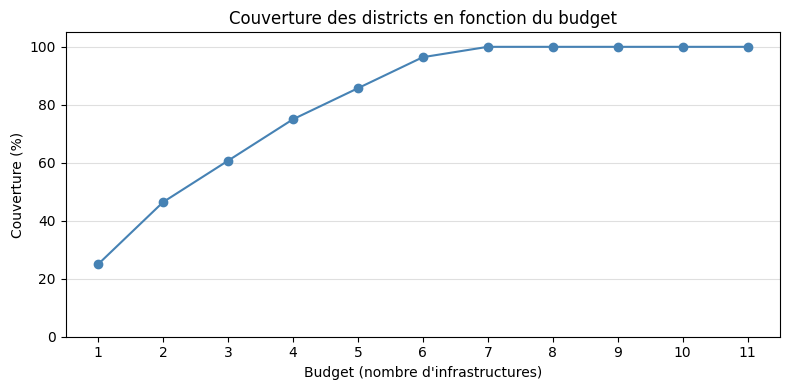

In [11]:
n_districts_total = len(gpd.read_file(DISTRICTS_PATH))
budgets = list(range(1, 12))
coverage_pct = []

print("Ablation budget (equity_weight=0, couverture pure)")
for b in budgets:
    res = solve(
        districts_path=DISTRICTS_PATH,
        sites_path=SITES_PATH,
        budget=b,
        radius_km=RADIUS_KM,
        equity_weight=0.0,
        timeout_s=30,
    )
    pct = 100 * len(res.covered_districts) / n_districts_total if n_districts_total else 0
    coverage_pct.append(pct)
    print(f"  Budget={b:2d} \u2192 {len(res.covered_districts)}/{n_districts_total} districts ({pct:.0f}%)")

plt.figure(figsize=(8, 4))
plt.plot(budgets, coverage_pct, marker="o", color="steelblue")
plt.xlabel("Budget (nombre d'infrastructures)")
plt.ylabel("Couverture (%)")
plt.title("Couverture des districts en fonction du budget")
plt.xticks(budgets)
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

### 6.2 Impact de l'équité

Comparaison entre une optimisation purement axée couverture (`equity_weight=0`) et une fortement équitable (`equity_weight=3`) avec le même budget.

28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 9/10
Districts covered: 28/28 (100%)
Equity gap       : 1 site(s)
Solve time       : 0.16s
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 7/10
Districts covered: 28/28 (100%)
Equity gap       : 0 site(s)
Solve time       : 0.21s


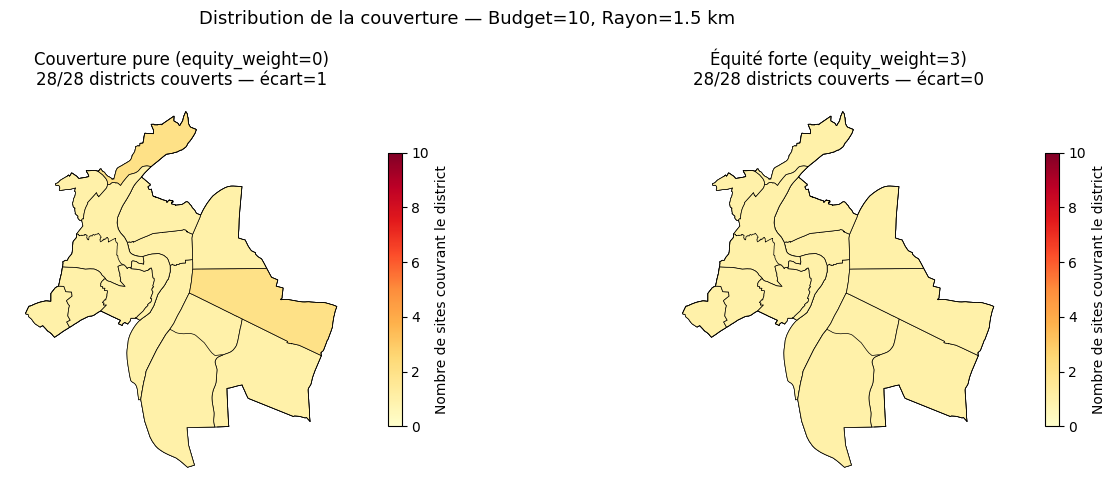

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ew, label in [
    (axes[0], 0.0, "Couverture pure (equity_weight=0)"),
    (axes[1], 3.0, "\u00c9quit\u00e9 forte (equity_weight=3)"),
]:
    res = solve(
        districts_path=DISTRICTS_PATH,
        sites_path=SITES_PATH,
        budget=BUDGET * 2,
        radius_km=RADIUS_KM,
        equity_weight=ew,
        timeout_s=30,
    )

    districts_gdf = gpd.read_file(DISTRICTS_PATH)
    districts_gdf["cov_count"] = res.district_coverage_count

    districts_gdf.plot(
        column="cov_count",
        cmap="YlOrRd",
        vmin=0,
        vmax=BUDGET * 2,
        linewidth=0.5,
        edgecolor="black",
        ax=ax,
        legend=True,
        legend_kwds={"label": "Nombre de sites couvrant le district", "shrink": 0.7},
    )
    n_covered = len(res.covered_districts)
    covered_counts = [res.district_coverage_count[d] for d in res.covered_districts]
    gap = max(covered_counts) - min(covered_counts) if covered_counts else 0
    ax.set_title(f"{label}\n" f"{n_covered}/{n_districts_total} districts couverts — écart={gap}")
    ax.axis("off")

plt.suptitle(
    f"Distribution de la couverture — Budget={BUDGET * 2}, Rayon={RADIUS_KM} km",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### 6.3 Impact du rayon de couverture

Un rayon plus grand couvre plus de districts mais peut rendre les contraintes d'équité plus faciles à satisfaire.

Ablation rayon de couverture (budget fixe, equity_weight=1)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 27/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 5/5
Districts covered: 10/28 (35%)
Equity gap       : 7 site(s)
Solve time       : 0.03s
  radius=0.5 km → 10/28 (36%)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 5/5
Districts covered: 18/28 (64%)
Equity gap       : 7 site(s)
Solve time       : 0.07s
  radius=1.0 km → 18/28 (64%)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMAL
Sites selected   : 5/5
Districts covered: 24/28 (85%)
Equity gap       : 7 site(s)
Solve time       : 0.17s
  radius=1.5 km → 24/28 (86%)
28 districts, 1232 candidate sites.
Districts coverable (≥1 site in radius): 28/28
Running CP-SAT solver...
Status        : OPTIMA

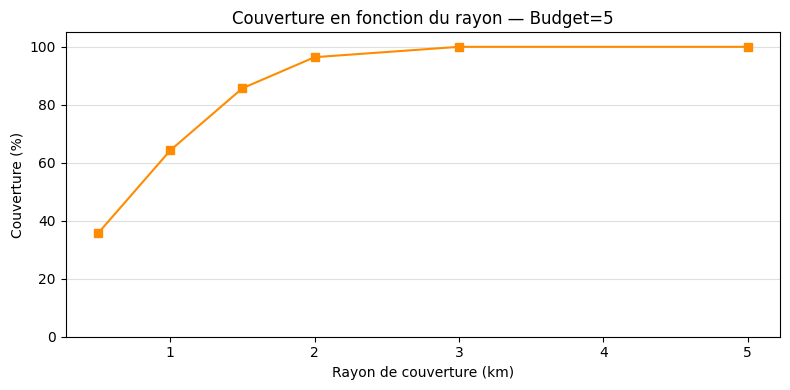

In [13]:
radii = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
cov_by_radius = []

print("Ablation rayon de couverture (budget fixe, equity_weight=1)")
for r in radii:
    res = solve(
        districts_path=DISTRICTS_PATH,
        sites_path=SITES_PATH,
        budget=BUDGET,
        radius_km=r,
        equity_weight=1.0,
        timeout_s=30,
    )
    pct = 100 * len(res.covered_districts) / n_districts_total if n_districts_total else 0
    cov_by_radius.append(pct)
    print(f"  radius={r:.1f} km \u2192 {len(res.covered_districts)}/{n_districts_total} ({pct:.0f}%)")

plt.figure(figsize=(8, 4))
plt.plot(radii, cov_by_radius, marker="s", color="darkorange")
plt.xlabel("Rayon de couverture (km)")
plt.ylabel("Couverture (%)")
plt.title(f"Couverture en fonction du rayon \u2014 Budget={BUDGET}")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()